<a href="https://colab.research.google.com/github/MyTeachers123/genai-course/blob/main/week1/homework/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1**

In [6]:
import os
import zipfile
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [8]:
zip_path = "/simplified_staff_dataset_510.zip"
extract_path = "/content/music_notes"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [9]:
class MusicNotesDataset(Dataset):
    def __init__(self, folder):
        self.files = []

        for root, dirs, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(".png"):
                    self.files.append(os.path.join(root, file))

        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((32, 32)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = Image.open(self.files[index])
        image = self.transform(image)
        return image

In [10]:
music_dataset = MusicNotesDataset(extract_path)

music_loader = DataLoader(
    music_dataset,
    batch_size=64,
    shuffle=True
)

print("Number of images:", len(music_dataset))

Number of images: 510


In [11]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_var = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 32, 32))
        )

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)

        mu = self.fc_mu(h)
        log_var = self.fc_var(h)

        z = self.reparameterise(mu, log_var)
        recon = self.decoder(z)

        return recon, mu, log_var

In [12]:
def vae_loss(recon, x, mu, log_var):
    recon_loss = nn.functional.binary_cross_entropy(
        recon, x, reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    )

    return recon_loss + kl_loss

In [13]:
vae = VAE(latent_dim=16).to(device)

optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3
)

epochs = 30

for epoch in range(epochs):
    vae.train()
    total_loss = 0

    for x in music_loader:
        x = x.to(device)

        recon, mu, log_var = vae(x)
        loss = vae_loss(recon, x, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(music_dataset)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {average_loss:.2f}"
    )

Epoch 1/30, Loss: 626.36
Epoch 2/30, Loss: 322.47
Epoch 3/30, Loss: 199.67
Epoch 4/30, Loss: 177.54
Epoch 5/30, Loss: 171.16
Epoch 6/30, Loss: 167.73
Epoch 7/30, Loss: 166.77
Epoch 8/30, Loss: 165.20
Epoch 9/30, Loss: 164.82
Epoch 10/30, Loss: 164.36
Epoch 11/30, Loss: 164.02
Epoch 12/30, Loss: 163.44
Epoch 13/30, Loss: 162.84
Epoch 14/30, Loss: 162.94
Epoch 15/30, Loss: 162.98
Epoch 16/30, Loss: 162.71
Epoch 17/30, Loss: 162.47
Epoch 18/30, Loss: 162.20
Epoch 19/30, Loss: 161.74
Epoch 20/30, Loss: 161.30
Epoch 21/30, Loss: 161.60
Epoch 22/30, Loss: 161.58
Epoch 23/30, Loss: 161.07
Epoch 24/30, Loss: 161.00
Epoch 25/30, Loss: 160.70
Epoch 26/30, Loss: 160.43
Epoch 27/30, Loss: 160.51
Epoch 28/30, Loss: 160.29
Epoch 29/30, Loss: 160.10
Epoch 30/30, Loss: 159.73


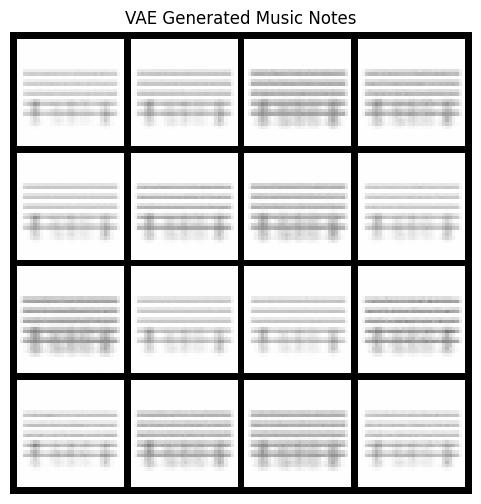

In [21]:
vae.eval()

with torch.no_grad():
    z = torch.randn(16, 16).to(device)
    generated = vae.decoder(z).cpu()

grid = make_grid(
    generated,
    nrow=4,
    padding=2
)

plt.figure(figsize=(6, 6))
plt.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray"
)
plt.axis("off")
plt.title("VAE Generated Music Notes")
plt.show()

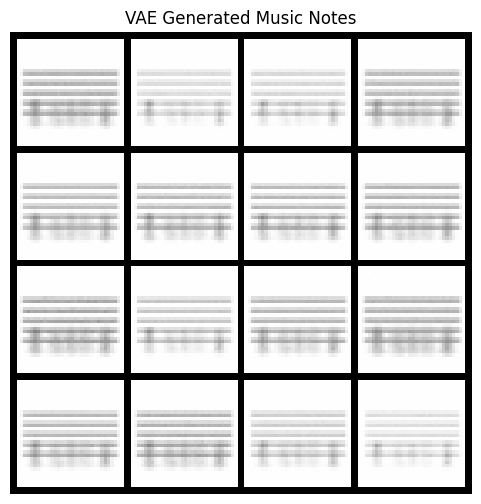

In [15]:
os.makedirs("/content/images", exist_ok=True)

plt.figure(figsize=(6, 6))
plt.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray"
)
plt.axis("off")
plt.title("VAE Generated Music Notes")

plt.savefig(
    "/content/images/vae_generated_4x4.png",
    bbox_inches="tight"
)

plt.show()

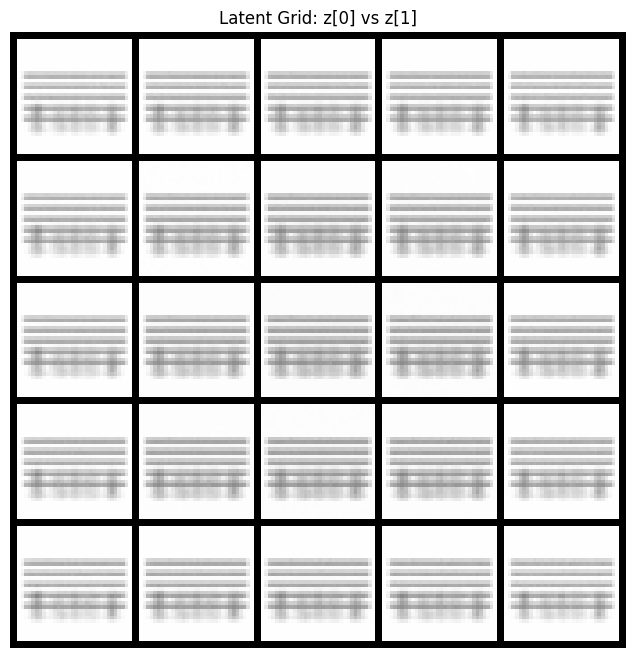

In [16]:
import numpy as np

vae.eval()

values = np.linspace(-2, 2, 5)

latent_images = []

with torch.no_grad():
    for z1 in values:
        for z2 in values:
            z = torch.zeros(1, 16).to(device)

            z[0, 0] = z1
            z[0, 1] = z2

            image = vae.decoder(z).cpu()
            latent_images.append(image)

latent_images = torch.cat(latent_images, dim=0)

latent_grid = make_grid(
    latent_images,
    nrow=5,
    padding=2
)

plt.figure(figsize=(8, 8))
plt.imshow(
    latent_grid.permute(1, 2, 0).squeeze(),
    cmap="gray"
)
plt.axis("off")
plt.title("Latent Grid: z[0] vs z[1]")

plt.savefig(
    "/content/images/vae_latent_grid.png",
    bbox_inches="tight"
)

plt.show()

**Part 2**

In [17]:
from torchvision import datasets

gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

gan_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=gan_transform
)

gan_loader = DataLoader(
    gan_dataset,
    batch_size=128,
    shuffle=True
)

print("GAN training images:", len(gan_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 65.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.46MB/s]

GAN training images: 60000


In [18]:
class Generator(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 784),
            nn.Tanh(),

            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [19]:
def train_gan(lr_g, lr_d, epochs=30):
    G = Generator().to(device)
    D = Discriminator().to(device)

    criterion = nn.BCELoss()

    optimizer_G = torch.optim.Adam(
        G.parameters(),
        lr=lr_g,
        betas=(0.5, 0.999)
    )

    optimizer_D = torch.optim.Adam(
        D.parameters(),
        lr=lr_d,
        betas=(0.5, 0.999)
    )

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        g_epoch_loss = 0
        d_epoch_loss = 0

        for real, _ in gan_loader:
            real = real.to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(
                batch_size, 1, device=device
            )

            fake_labels = torch.zeros(
                batch_size, 1, device=device
            )

            # Train Discriminator
            z = torch.randn(
                batch_size, 64, device=device
            )

            fake = G(z)

            real_loss = criterion(
                D(real), real_labels
            )

            fake_loss = criterion(
                D(fake.detach()), fake_labels
            )

            d_loss = real_loss + fake_loss

            optimizer_D.zero_grad()
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            z = torch.randn(
                batch_size, 64, device=device
            )

            fake = G(z)

            g_loss = criterion(
                D(fake), real_labels
            )

            optimizer_G.zero_grad()
            g_loss.backward()
            optimizer_G.step()

            g_epoch_loss += g_loss.item()
            d_epoch_loss += d_loss.item()

        g_losses.append(
            g_epoch_loss / len(gan_loader)
        )

        d_losses.append(
            d_epoch_loss / len(gan_loader)
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"D Loss: {d_losses[-1]:.4f} | "
            f"G Loss: {g_losses[-1]:.4f}"
        )

    return G, D, g_losses, d_losses

In [20]:
G_standard, D_standard, g_loss_standard, d_loss_standard = train_gan(
    lr_g=2e-4,
    lr_d=2e-4,
    epochs=30
)

Epoch 1/30 | D Loss: 1.0642 | G Loss: 0.9670
Epoch 2/30 | D Loss: 0.6373 | G Loss: 2.1073
Epoch 3/30 | D Loss: 0.4501 | G Loss: 2.9871
Epoch 4/30 | D Loss: 0.5010 | G Loss: 2.8680
Epoch 5/30 | D Loss: 0.4974 | G Loss: 3.0610
Epoch 6/30 | D Loss: 0.4798 | G Loss: 3.2251
Epoch 7/30 | D Loss: 0.4012 | G Loss: 3.7561
Epoch 8/30 | D Loss: 0.3681 | G Loss: 3.5995
Epoch 9/30 | D Loss: 0.3629 | G Loss: 3.5712
Epoch 10/30 | D Loss: 0.3288 | G Loss: 3.8728
Epoch 11/30 | D Loss: 0.3286 | G Loss: 3.7016
Epoch 12/30 | D Loss: 0.3535 | G Loss: 3.3513
Epoch 13/30 | D Loss: 0.3198 | G Loss: 3.8103
Epoch 14/30 | D Loss: 0.3123 | G Loss: 3.6829
Epoch 15/30 | D Loss: 0.3653 | G Loss: 3.4059
Epoch 16/30 | D Loss: 0.3581 | G Loss: 3.4421
Epoch 17/30 | D Loss: 0.3774 | G Loss: 3.4862
Epoch 18/30 | D Loss: 0.4115 | G Loss: 3.1971
Epoch 19/30 | D Loss: 0.4829 | G Loss: 3.0153
Epoch 20/30 | D Loss: 0.5570 | G Loss: 2.8049
Epoch 21/30 | D Loss: 0.5143 | G Loss: 2.9626
Epoch 22/30 | D Loss: 0.5259 | G Loss: 3.07

In [22]:
G_unbalanced, D_unbalanced, g_loss_unbalanced, d_loss_unbalanced = train_gan(
    lr_g=2e-4,
    lr_d=2e-3,
    epochs=30
)

Epoch 1/30 | D Loss: 0.7374 | G Loss: 1.6669
Epoch 2/30 | D Loss: 0.4239 | G Loss: 2.9657
Epoch 3/30 | D Loss: 0.4861 | G Loss: 2.7002
Epoch 4/30 | D Loss: 0.4073 | G Loss: 2.9320
Epoch 5/30 | D Loss: 0.3417 | G Loss: 3.0016
Epoch 6/30 | D Loss: 0.3499 | G Loss: 2.9537
Epoch 7/30 | D Loss: 0.3671 | G Loss: 2.6767
Epoch 8/30 | D Loss: 0.3668 | G Loss: 2.6569
Epoch 9/30 | D Loss: 0.3601 | G Loss: 2.6425
Epoch 10/30 | D Loss: 0.3615 | G Loss: 2.6232
Epoch 11/30 | D Loss: 0.3673 | G Loss: 2.5854
Epoch 12/30 | D Loss: 0.7503 | G Loss: 2.7624
Epoch 13/30 | D Loss: 0.4756 | G Loss: 2.2217
Epoch 14/30 | D Loss: 0.4509 | G Loss: 2.3597
Epoch 15/30 | D Loss: 0.4450 | G Loss: 2.4107
Epoch 16/30 | D Loss: 0.4560 | G Loss: 2.4043
Epoch 17/30 | D Loss: 0.4676 | G Loss: 2.3631
Epoch 18/30 | D Loss: 0.4855 | G Loss: 2.3537
Epoch 19/30 | D Loss: 0.5090 | G Loss: 2.3234
Epoch 20/30 | D Loss: 0.5131 | G Loss: 2.3273
Epoch 21/30 | D Loss: 0.5175 | G Loss: 2.3125
Epoch 22/30 | D Loss: 0.5405 | G Loss: 2.27

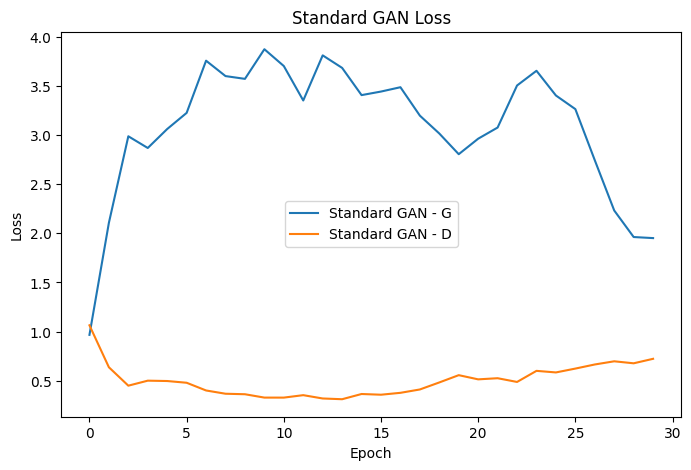

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    g_loss_standard,
    label="Standard GAN - G"
)

plt.plot(
    d_loss_standard,
    label="Standard GAN - D"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Standard GAN Loss")
plt.legend()

plt.savefig(
    "/content/images/standard_gan_loss.png",
    bbox_inches="tight"
)

plt.show()

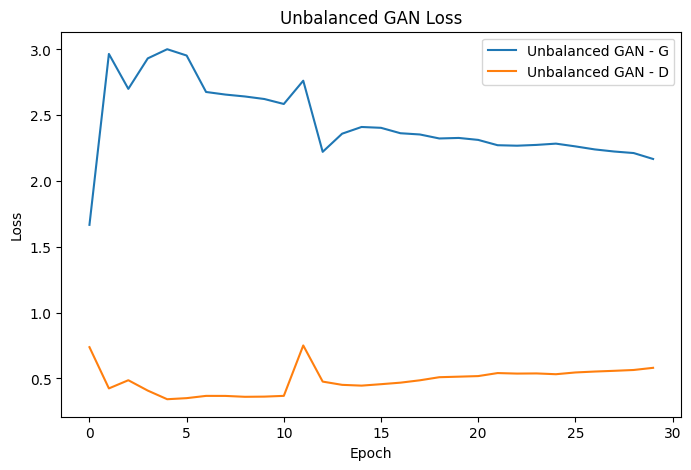

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    g_loss_unbalanced,
    label="Unbalanced GAN - G"
)

plt.plot(
    d_loss_unbalanced,
    label="Unbalanced GAN - D"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Unbalanced GAN Loss")
plt.legend()

plt.savefig(
    "/content/images/unbalanced_gan_loss.png",
    bbox_inches="tight"
)

plt.show()

**Experiment C — WGAN-GP**

In [25]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

In [26]:
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)

    alpha = torch.rand(
        batch_size, 1, 1, 1,
        device=device
    )

    interpolated = (
        alpha * real +
        (1 - alpha) * fake
    )

    interpolated.requires_grad_(True)

    scores = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(
        batch_size, -1
    )

    penalty = (
        (gradients.norm(2, dim=1) - 1) ** 2
    ).mean()

    return penalty

**Train WGAN-GP**

In [27]:
def train_wgan_gp(epochs=30):
    G = Generator().to(device)
    C = Critic().to(device)

    optimizer_G = torch.optim.Adam(
        G.parameters(),
        lr=1e-4,
        betas=(0.0, 0.9)
    )

    optimizer_C = torch.optim.Adam(
        C.parameters(),
        lr=1e-4,
        betas=(0.0, 0.9)
    )

    g_losses = []
    c_losses = []

    lambda_gp = 10

    for epoch in range(epochs):
        g_epoch_loss = 0
        c_epoch_loss = 0

        for real, _ in gan_loader:
            real = real.to(device)
            batch_size = real.size(0)

            # Train Critic
            z = torch.randn(
                batch_size, 64,
                device=device
            )

            fake = G(z)

            real_score = C(real).mean()
            fake_score = C(fake.detach()).mean()

            gp = gradient_penalty(
                C,
                real,
                fake.detach(),
                device
            )

            c_loss = (
                fake_score
                - real_score
                + lambda_gp * gp
            )

            optimizer_C.zero_grad()
            c_loss.backward()
            optimizer_C.step()

            # Train Generator
            z = torch.randn(
                batch_size, 64,
                device=device
            )

            fake = G(z)

            g_loss = -C(fake).mean()

            optimizer_G.zero_grad()
            g_loss.backward()
            optimizer_G.step()

            g_epoch_loss += g_loss.item()
            c_epoch_loss += c_loss.item()

        g_losses.append(
            g_epoch_loss / len(gan_loader)
        )

        c_losses.append(
            c_epoch_loss / len(gan_loader)
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"C Loss: {c_losses[-1]:.4f} | "
            f"G Loss: {g_losses[-1]:.4f}"
        )

    return G, C, g_losses, c_losses

In [28]:
G_wgan, C_wgan, g_loss_wgan, c_loss_wgan = train_wgan_gp(
    epochs=30
)

Epoch 1/30 | C Loss: -1.4462 | G Loss: -13.1046
Epoch 2/30 | C Loss: -2.8967 | G Loss: -7.3914
Epoch 3/30 | C Loss: -6.2225 | G Loss: -2.2232
Epoch 4/30 | C Loss: -5.1181 | G Loss: -2.9614
Epoch 5/30 | C Loss: -4.5166 | G Loss: -1.9717
Epoch 6/30 | C Loss: -4.3217 | G Loss: -0.9683
Epoch 7/30 | C Loss: -4.3173 | G Loss: 1.4737
Epoch 8/30 | C Loss: -4.3424 | G Loss: 2.9536
Epoch 9/30 | C Loss: -4.2421 | G Loss: 3.8391
Epoch 10/30 | C Loss: -3.9747 | G Loss: 3.7338
Epoch 11/30 | C Loss: -3.9401 | G Loss: 4.0823
Epoch 12/30 | C Loss: -3.9230 | G Loss: 4.6400
Epoch 13/30 | C Loss: -3.6763 | G Loss: 4.0568
Epoch 14/30 | C Loss: -3.6440 | G Loss: 3.2333
Epoch 15/30 | C Loss: -3.5683 | G Loss: 3.2407
Epoch 16/30 | C Loss: -3.0804 | G Loss: 2.7229
Epoch 17/30 | C Loss: -3.0848 | G Loss: 2.3137
Epoch 18/30 | C Loss: -2.9007 | G Loss: 2.8307
Epoch 19/30 | C Loss: -2.8734 | G Loss: 1.7295
Epoch 20/30 | C Loss: -2.6675 | G Loss: 1.6870
Epoch 21/30 | C Loss: -2.6909 | G Loss: 1.6498
Epoch 22/30 | C

**WGAN-GP Loss Plot**

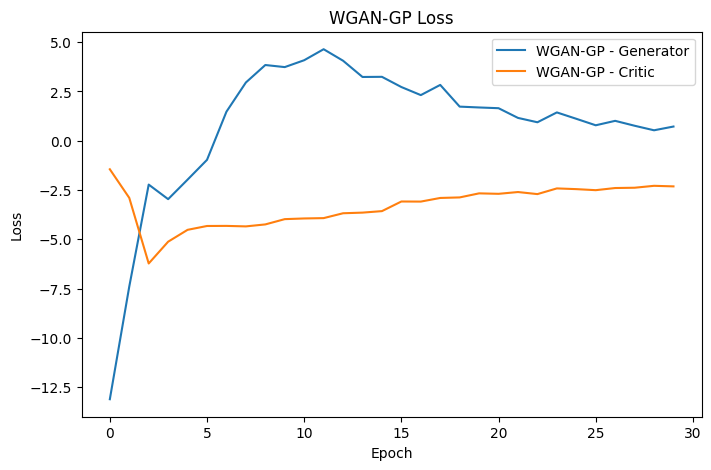

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    g_loss_wgan,
    label="WGAN-GP - Generator"
)

plt.plot(
    c_loss_wgan,
    label="WGAN-GP - Critic"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Loss")
plt.legend()

plt.savefig(
    "/content/images/wgan_gp_loss.png",
    bbox_inches="tight"
)

plt.show()

**Save Function**

In [30]:
from torchvision.utils import save_image

def generate_and_save(model, folder, num_images=500):
    os.makedirs(folder, exist_ok=True)

    model.eval()

    with torch.no_grad():
        z = torch.randn(num_images, 64).to(device)
        images = model(z).cpu()

        # Tanh output: [-1, 1] -> image range: [0, 1]
        images = (images + 1) / 2

    for i in range(num_images):
        save_image(
            images[i],
            f"{folder}/{i}.png"
        )

    return images

In [31]:
standard_images = generate_and_save(
    G_standard,
    "/content/gan_standard",
    500
)

unbalanced_images = generate_and_save(
    G_unbalanced,
    "/content/gan_unbalanced",
    500
)

wgan_images = generate_and_save(
    G_wgan,
    "/content/wgan_gp",
    500
)

print("Generated 500 images for each model.")

Generated 500 images for each model.


**3 groups of 4 x 4 samples**

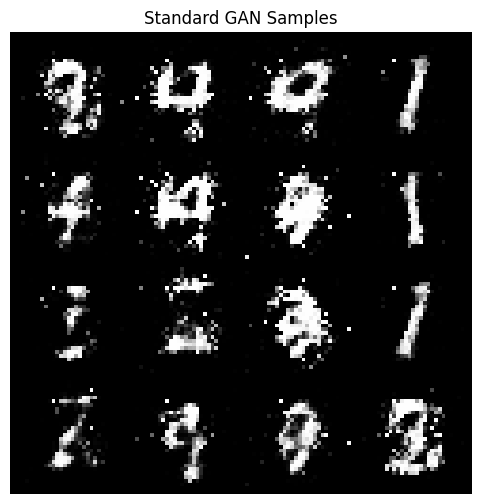

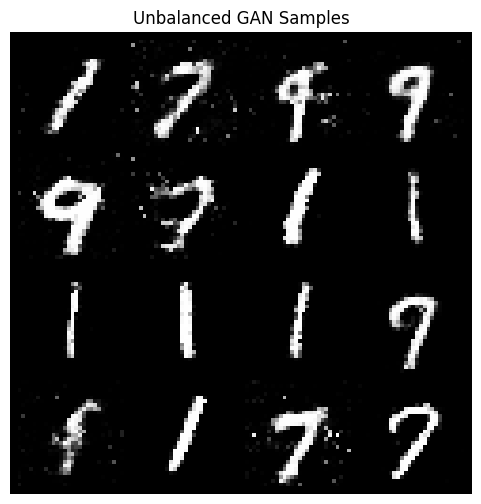

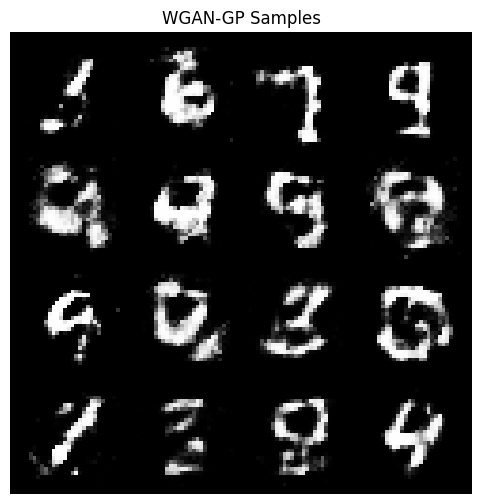

In [32]:
def show_samples(images, title, filename):
    grid = make_grid(
        images[:16],
        nrow=4,
        padding=2
    )

    plt.figure(figsize=(6, 6))

    plt.imshow(
        grid.permute(1, 2, 0).squeeze(),
        cmap="gray"
    )

    plt.axis("off")
    plt.title(title)

    plt.savefig(
        f"/content/images/{filename}",
        bbox_inches="tight"
    )

    plt.show()


show_samples(
    standard_images,
    "Standard GAN Samples",
    "standard_gan_samples.png"
)

show_samples(
    unbalanced_images,
    "Unbalanced GAN Samples",
    "unbalanced_gan_samples.png"
)

show_samples(
    wgan_images,
    "WGAN-GP Samples",
    "wgan_gp_samples.png"
)

**Diversity among 50 samples**

In [33]:
def diversity_score(images, num_samples=50):
    samples = images[:num_samples]

    samples = samples.view(
        num_samples, -1
    )

    distances = torch.pdist(
        samples,
        p=2
    )

    return distances.mean().item()


div_standard = diversity_score(
    standard_images
)

div_unbalanced = diversity_score(
    unbalanced_images
)

div_wgan = diversity_score(
    wgan_images
)

print("Standard GAN Diversity:", div_standard)
print("Unbalanced GAN Diversity:", div_unbalanced)
print("WGAN-GP Diversity:", div_wgan)

Standard GAN Diversity: 8.973108291625977
Unbalanced GAN Diversity: 8.09339714050293
WGAN-GP Diversity: 9.625185012817383


**500 Real MNIST**

In [34]:
os.makedirs(
    "/content/real_mnist",
    exist_ok=True
)

saved = 0

for real, _ in gan_loader:
    real = real.cpu()

    # [-1, 1] -> [0, 1]
    real = (real + 1) / 2

    for image in real:
        save_image(
            image,
            f"/content/real_mnist/{saved}.png"
        )

        saved += 1

        if saved >= 500:
            break

    if saved >= 500:
        break

print("Real MNIST images saved:", saved)

Real MNIST images saved: 500


In [35]:
!pip install pytorch-fid --quiet

In [36]:
!python -m pytorch_fid /content/real_mnist /content/gan_standard

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 172MB/s]
100% 10/10 [03:14<00:00, 19.47s/it]
100% 10/10 [03:11<00:00, 19.15s/it]
FID:  175.38877111359244


In [37]:
!python -m pytorch_fid /content/real_mnist /content/gan_unbalanced

100% 10/10 [03:14<00:00, 19.43s/it]
100% 10/10 [03:13<00:00, 19.31s/it]
FID:  116.7398848521621


In [38]:
!python -m pytorch_fid /content/real_mnist /content/wgan_gp

100% 10/10 [03:06<00:00, 18.70s/it]
100% 10/10 [03:08<00:00, 18.86s/it]
FID:  116.65266619874063


**Results Table**

In [41]:
# Fill these in after FID calculation
fid_standard = 175.38877111359244
fid_unbalanced = 116.7398848521621
fid_wgan = 116.65266619874063

print("\nPart 2 Results")
print("-" * 65)
print(f"{'Model':<20} {'FID':<20} {'Diversity':<20}")
print("-" * 65)

print(
    f"{'Standard GAN':<20} "
    f"{str(fid_standard):<20} "
    f"{div_standard:<20.4f}"
)

print(
    f"{'Unbalanced GAN':<20} "
    f"{str(fid_unbalanced):<20} "
    f"{div_unbalanced:<20.4f}"
)

print(
    f"{'WGAN-GP':<20} "
    f"{str(fid_wgan):<20} "
    f"{div_wgan:<20.4f}"
)

print("-" * 65)


Part 2 Results
-----------------------------------------------------------------
Model                FID                  Diversity           
-----------------------------------------------------------------
Standard GAN         175.38877111359244   8.9731              
Unbalanced GAN       116.7398848521621    8.0934              
WGAN-GP              116.65266619874063   9.6252              
-----------------------------------------------------------------
